<a href="https://colab.research.google.com/github/syedarhabjafri/supply-chain-analytics-SAUJ/blob/main/FFC_Forecast_Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FFC Sona Urea — 12-week holdout forecast comparison

*Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Fauji Fertilizer Company Limited's disclosed scale, not actual company records.*

Run all cells in order. Cell 1 asks you to upload `FFC_Sona_Urea_Synthetic_Weekly_v2_FROZEN.csv`. Every model is fitted on `train_df` only; `test_df` (last 12 weeks) is used only for scoring.

In [1]:
# =====================================================================
# FFC Sona Urea — 12-week holdout comparison of forecasting methods
# Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative
# figures, calibrated to Fauji Fertilizer Company Limited's disclosed scale,
# not actual company records.
# =====================================================================

In [2]:
# %% [1] Setup and data -------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LABEL = ("Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, "
         "calibrated to Fauji Fertilizer Company Limited's disclosed scale, not actual company records.")
CSV_NAME = "FFC_Sona_Urea_Synthetic_Weekly_v2_FROZEN.csv"
HOLDOUT = 12

try:                                   # In Colab: upload the frozen CSV when prompted
    from google.colab import files
    import os
    if not os.path.exists(CSV_NAME):
        files.upload()
except ImportError:
    pass                               # Running outside Colab: CSV must be in the working folder

df = pd.read_csv(CSV_NAME, parse_dates=["Week_Start_Date"]).sort_values("Week_Start_Date").reset_index(drop=True)

# Skip this split if you already have train_df / test_df
train_df = df.iloc[:-HOLDOUT].copy()
test_df  = df.iloc[-HOLDOUT:].copy()

# Leakage guard: test must come strictly after train, and models only ever see train_df
assert train_df["Week_Start_Date"].max() < test_df["Week_Start_Date"].min()
y_train = train_df["Actual_Demand"].to_numpy(dtype=float)
y_test  = test_df["Actual_Demand"].to_numpy(dtype=float)
H = len(test_df)
print(f"Train: {train_df.Week_Start_Date.min().date()} to {train_df.Week_Start_Date.max().date()} ({len(train_df)} weeks)")
print(f"Test : {test_df.Week_Start_Date.min().date()} to {test_df.Week_Start_Date.max().date()} ({H} weeks)")

# All forecasts below are made ONCE, from the last training week, for all 12 test weeks
# (fixed-origin, 1- to 12-step-ahead). Nothing is updated with test actuals.
forecasts = {}

Saving FFC_Sona_Urea_Synthetic_Weekly_v2_FROZEN.csv to FFC_Sona_Urea_Synthetic_Weekly_v2_FROZEN.csv
Train: 2023-01-02 to 2025-09-29 (144 weeks)
Test : 2025-10-06 to 2025-12-22 (12 weeks)


In [3]:
# %% [2] Naive and Seasonal Naive ---------------------------------------
forecasts["Naive"] = np.repeat(y_train[-1], H)                       # last observed week, held flat
season = 52
forecasts["Seasonal Naive"] = y_train[len(y_train) - season : len(y_train) - season + H]  # same week last year (all in train)

In [4]:
# %% [3] Simple Moving Average (4-week) ---------------------------------
forecasts["Moving Average (4 wk)"] = np.repeat(y_train[-4:].mean(), H)

In [5]:
# %% [4] Simple Exponential Smoothing (alpha 0.3 and 0.6) ---------------
def ses_level(series, alpha):
    level = series[0]
    for value in series[1:]:
        level = alpha * value + (1 - alpha) * level
    return level

forecasts["SES (alpha 0.3)"] = np.repeat(ses_level(y_train, 0.3), H)
forecasts["SES (alpha 0.6)"] = np.repeat(ses_level(y_train, 0.6), H)

In [6]:
# %% [5] Seasonal decomposition + Event_Flag + smoothed level -----------
# Step a: put all weeks on the same business scope. Port Qasim urea joins FFC from Jul 2024
#         (Merger_Flag = 1). Scope factor from the 2025 annual report: 2,886 / (2,886 - 449) = 1.184.
MERGER_SCOPE = 2886 / (2886 - 449)
if "Merger_Flag" in train_df.columns:
    scope_train = np.where(train_df["Merger_Flag"] == 1, 1.0, MERGER_SCOPE)
    scope_test  = np.where(test_df["Merger_Flag"] == 1, 1.0, 1 / MERGER_SCOPE)
else:
    scope_train = np.ones(len(train_df)); scope_test = np.ones(H)
y_scoped = y_train * scope_train

# Step b: estimate seasonality (12 monthly indices) and the Event_Flag uplift together,
#         on TRAIN ONLY, as log(demand / 52-week centred moving average) ~ month + Event_Flag
month_train = (train_df["Week_Start_Date"] + pd.Timedelta(days=3)).dt.month.to_numpy()
month_test  = (test_df["Week_Start_Date"]  + pd.Timedelta(days=3)).dt.month.to_numpy()
cma = pd.Series(y_scoped).rolling(52, center=True).mean().rolling(2).mean().shift(-1).to_numpy()
ok = ~np.isnan(cma)
X = np.column_stack([(month_train == m).astype(float) for m in range(1, 13)] + [train_df["Event_Flag"].to_numpy(float)])
coef, *_ = np.linalg.lstsq(X[ok], np.log(y_scoped[ok] / cma[ok]), rcond=None)
seasonal_index = np.exp(coef[:12]); seasonal_index /= np.exp(np.log(seasonal_index).mean())
event_factor = np.exp(coef[12])
print("\nMonthly seasonal index:", dict(zip(range(1, 13), seasonal_index.round(2))))
print(f"Event_Flag uplift on top of month: x{event_factor:.3f}")

# Step c: remove seasonality and event effect, then smooth the remaining level.
#         Alpha chosen by one-step-ahead error on TRAIN ONLY.
fac_train = seasonal_index[month_train - 1] * np.where(train_df["Event_Flag"] == 1, event_factor, 1.0)
z = y_scoped / fac_train
best = None
for a in np.arange(0.05, 0.96, 0.05):
    level, sse = z[0], 0.0
    for v in z[1:]:
        sse += (v - level) ** 2
        level = a * v + (1 - a) * level
    if best is None or sse < best[0]:
        best = (sse, a, level)
_, alpha_star, final_level = best
print(f"Level smoothing alpha (fit on train): {alpha_star:.2f}")

# Step d: forecast = level x month index x event uplift (Event_Flag is a calendar known in advance)
fac_test = seasonal_index[month_test - 1] * np.where(test_df["Event_Flag"] == 1, event_factor, 1.0)
forecasts["Seasonal Decomp + Event"] = final_level * fac_test * scope_test


Monthly seasonal index: {1: np.float64(1.07), 2: np.float64(0.84), 3: np.float64(0.75), 4: np.float64(0.91), 5: np.float64(1.03), 6: np.float64(1.09), 7: np.float64(0.99), 8: np.float64(0.98), 9: np.float64(0.94), 10: np.float64(1.04), 11: np.float64(1.14), 12: np.float64(1.34)}
Event_Flag uplift on top of month: x1.060
Level smoothing alpha (fit on train): 0.35


In [7]:
# %% [6] Model comparison table -----------------------------------------
def metrics(actual, forecast):
    err = actual - forecast                      # Error = Actual - Forecast (+ = under-forecast)
    mad = np.abs(err).mean()
    return {"MAD": mad,
            "MAPE %": np.mean(np.abs(err) / actual) * 100,
            "RMSE": np.sqrt(np.mean(err ** 2)),
            "WAPE %": np.abs(err).sum() / actual.sum() * 100,
            "Bias": err.mean(),
            "Tracking Signal": err.sum() / mad}

table = pd.DataFrame({name: metrics(y_test, f) for name, f in forecasts.items()}).T
table = table.sort_values("WAPE %")
pd.options.display.float_format = "{:,.1f}".format
print("\n" + LABEL)
print("12-week holdout results (tonnes; Error = Actual - Forecast)")
try:
    display(table)          # Colab / Jupyter
except NameError:
    print(table.to_string())


Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Fauji Fertilizer Company Limited's disclosed scale, not actual company records.
12-week holdout results (tonnes; Error = Actual - Forecast)


,MAD,MAPE %,RMSE,WAPE %,Bias,Tracking Signal
Seasonal Decomp + Event,"10,626.4",18.3,"13,398.9",14.6,"-3,274.3",-3.7
Seasonal Naive,"12,623.3",18.3,"14,717.9",17.4,"7,446.7",7.1
Moving Average (4 wk),"18,086.7",25.5,"22,368.6",24.9,"8,585.0",5.7
SES (alpha 0.6),"18,877.1",25.8,"23,381.5",26.0,"10,956.4",7.0
SES (alpha 0.3),"18,974.4",25.9,"23,519.6",26.1,"11,248.2",7.1
Naive,"19,397.5",26.0,"24,152.4",26.7,"12,517.5",7.7


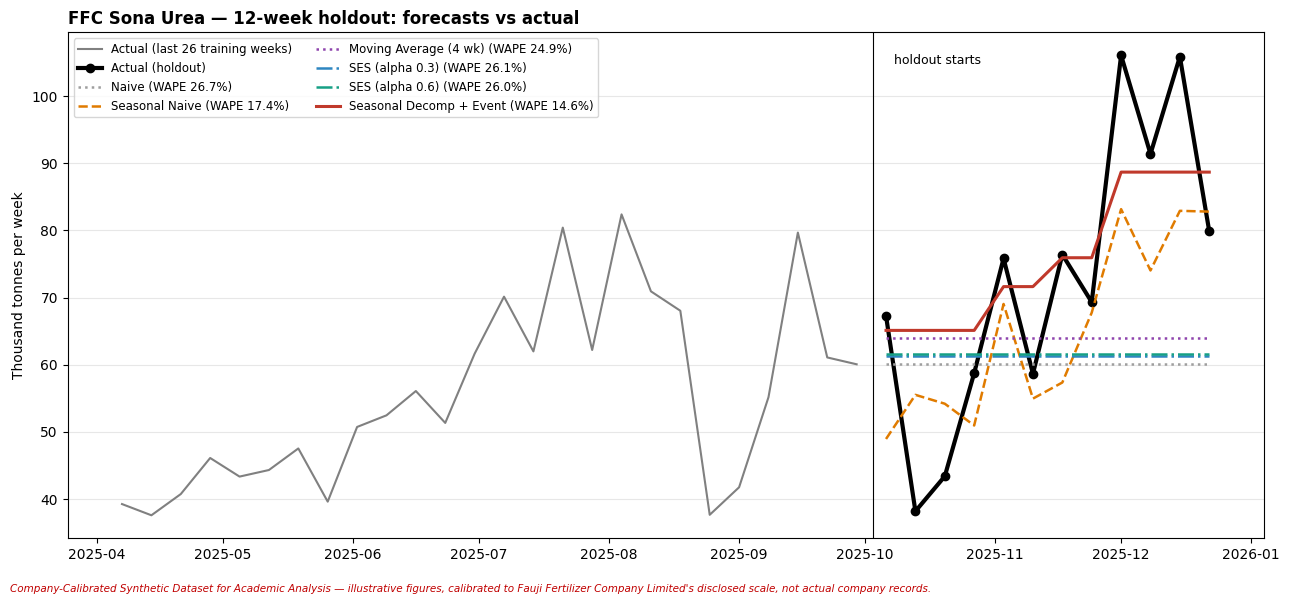

In [8]:
# %% [7] Plot all forecasts against actual test values ------------------
fig, ax = plt.subplots(figsize=(13, 6))
ctx = train_df.tail(26)
ax.plot(ctx["Week_Start_Date"], ctx["Actual_Demand"] / 1000, color="grey", lw=1.5, label="Actual (last 26 training weeks)")
ax.plot(test_df["Week_Start_Date"], y_test / 1000, color="black", lw=3, marker="o", label="Actual (holdout)")
styles = {"Naive": ("#9E9E9E", ":"), "Seasonal Naive": ("#E07B00", "--"), "Moving Average (4 wk)": ("#8E44AD", ":"),
          "SES (alpha 0.3)": ("#2E86C1", "-."), "SES (alpha 0.6)": ("#16A085", "-."), "Seasonal Decomp + Event": ("#C0392B", "-")}
for name, f in forecasts.items():
    c, ls = styles.get(name, (None, "-"))
    ax.plot(test_df["Week_Start_Date"], f / 1000, color=c, ls=ls, lw=2.2 if "Decomp" in name else 1.8,
            label=f"{name} (WAPE {table.loc[name, 'WAPE %']:.1f}%)")
ax.axvline(test_df["Week_Start_Date"].min() - pd.Timedelta(days=3), color="black", lw=0.8)
ax.text(test_df["Week_Start_Date"].min(), ax.get_ylim()[1] * 0.97, "  holdout starts", fontsize=9, va="top")
ax.set_ylabel("Thousand tonnes per week")
ax.set_title("FFC Sona Urea — 12-week holdout: forecasts vs actual", loc="left", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=8.5, loc="upper left", ncol=2)
fig.text(0.01, 0.005, LABEL, fontsize=7.5, color="#C00000", style="italic")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig("FFC_holdout_forecast_comparison.png", dpi=180)
plt.show()